# Análise de Dados: Preços de Laptops

## Objetivo do Projeto

Este notebook apresenta uma análise exploratória completa do dataset de preços de laptops obtido do Kaggle. O objetivo principal é aplicar técnicas de ciência de dados para compreender os fatores que influenciam o preço final de notebooks no mercado, incluindo:

1. **Limpeza e preparação dos dados** - Tratamento de valores ausentes, conversão de tipos e padronização de unidades
2. **Análise exploratória de dados (EDA)** - Investigação estatística das variáveis e suas relações
3. **Visualizações informativas** - Gráficos que revelam padrões e tendências nos dados
4. **Identificação de insights** - Descoberta de fatores críticos que determinam preços
5. **Conclusões e recomendações** - Síntese dos achados e sugestões práticas



---

# 1º escolher o dataset 
Escolhi usar o price of laptop porque eu tava olhando para comprar um recentemente e então essa foi a escolha para analise

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohidabdulrehman/laptop-price-dataset")

print("Path to dataset files:", path)

100%|██████████| 24.4k/24.4k [00:00<?, ?B/s]

Extracting files...
Path to dataset files: C:\Users\thiag\.cache\kagglehub\datasets\mohidabdulrehman\laptop-price-dataset\versions\1


# Carregar o dataset para analise

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

laptop_price = pd.read_csv("C:/Users/thiag/OneDrive/Documentos/Faculdade/LIA/lia1_2026_1/laptop_data.csv")

laptop_price.info()
laptop_price.describe()
str(laptop_price.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


"Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',\n       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],\n      dtype='object')"

# Olhar a cara do dataset

In [13]:
laptop_price.head(10)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


## 2. Limpeza e Transformação de Dados

Após o carregamento, identificamos que o dataset contém inconsistências estruturais e tipos de dados que precisam de ajuste para permitir cálculos matemáticos e análises estatísticas precisas.

### 2.1. Remoção de Colunas Irrelevantes
Muitas vezes, datasets provenientes de arquivos CSV trazem uma coluna chamada `Unnamed: 0`, que funciona apenas como um índice do arquivo original. Como o **pandas** já gera um novo índice automaticamente, removemos essa coluna para manter o DataFrame limpo e evitar redundância.

### 2.2. Padronização de Variáveis Numéricas
Algumas colunas que deveriam ser numéricas foram lidas como texto (`string`) devido à presença de unidades de medida nos valores. Para corrigir isso, realizamos as seguintes conversões:

* **RAM:** Remoção do sufixo **"GB"** e conversão para o tipo **inteiro**.
* **Peso (Weight):** Remoção do sufixo **"kg"** e conversão para o tipo **float** (ponto flutuante).

> **Por que isso é importante?** Sem essa conversão, não seria possível calcular médias, correlações ou plotar gráficos de dispersão envolvendo o peso e a memória dos laptops.

In [16]:

# 1. Remover a coluna de índice antigo
if 'Unnamed: 0' in laptop_price.columns:
    laptop_price.drop(columns=['Unnamed: 0'], inplace=True)

# 2. Limpar a coluna Ram: remover 'GB' e converter para int
laptop_price['Ram'] = laptop_price['Ram'].str.replace('GB', '').astype(int)

# 3. Limpar a coluna Weight: remover 'kg' e converter para float
laptop_price['Weight'] = laptop_price['Weight'].str.replace('kg', '').astype(float)

# Verificar o resultado
print(laptop_price[['Ram', 'Weight']].dtypes)
print(laptop_price.head())

Ram         int64
Weight    float64
dtype: object
  Company   TypeName  Inches                    ScreenResolution  \
0   Apple  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   
1   Apple  Ultrabook    13.3                            1440x900   
2      HP   Notebook    15.6                   Full HD 1920x1080   
3   Apple  Ultrabook    15.4  IPS Panel Retina Display 2880x1800   
4   Apple  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   

                          Cpu  Ram               Memory  \
0        Intel Core i5 2.3GHz    8            128GB SSD   
1        Intel Core i5 1.8GHz    8  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz    8            256GB SSD   
3        Intel Core i7 2.7GHz   16            512GB SSD   
4        Intel Core i5 3.1GHz    8            256GB SSD   

                            Gpu  OpSys  Weight        Price  
0  Intel Iris Plus Graphics 640  macOS    1.37   71378.6832  
1        Intel HD Graphics 6000  macOS    1.34   47895.5232  


# Converter o preço de INR para BRL

In [18]:
# 1. Definir a taxa de câmbio (INR para BRL)
taxa_inr_brl = 0.056

# 2. Criar a nova coluna em Real e arredondar para 2 casas decimais
laptop_price['Price_BRL'] = (laptop_price['Price'] * taxa_inr_brl).round(2)

# 3. (Opcional) Remover a coluna original em INR para não confundir na análise
# laptop_price.drop(columns=['Price'], inplace=True)

# Visualizar como ficou
print(laptop_price[['Company', 'TypeName', 'Price', 'Price_BRL']].head())

  Company   TypeName        Price  Price_BRL
0   Apple  Ultrabook   71378.6832    3997.21
1   Apple  Ultrabook   47895.5232    2682.15
2      HP   Notebook   30636.0000    1715.62
3   Apple  Ultrabook  135195.3360    7570.94
4   Apple  Ultrabook   96095.8080    5381.37


## 3. Análise Exploratória de Dados (EDA)

Com o dataset devidamente limpo e os tipos de dados corrigidos, iniciamos a fase de exploração. O objetivo aqui é testar hipóteses e responder a perguntas estratégicas que definem o valor de um laptop no mercado. 

Para esta análise, focaremos em quatro pilares fundamentais:

1.  **Relação Peso vs. Preço:** O porte físico do aparelho e sua portabilidade influenciam diretamente no custo final?
2.  **Análise de Branding (Taxa de Marca):** Existe um sobrepreço significativo apenas pelo nome da fabricante, ou os valores são justificados pelo hardware?
3.  **Impacto dos Componentes:** Qual peça de hardware (CPU, RAM, GPU) possui a maior correlação com o aumento do preço?
4.  **Custo-Benefício para Profissionais de Dados:** Considerando a necessidade de alta performance (RAM) e armazenamento (ROM) para lidar com grandes volumes de dados, quais modelos oferecem a melhor configuração pelo menor preço?

---
> **Nota do Analista:** Esta última pergunta é de interesse pessoal, unindo a ciência de dados com a minha busca recente por um novo notebook para trabalho.

# 1. Relação Peso vs Preço

A correlação entre Peso e Preço é: 0.21


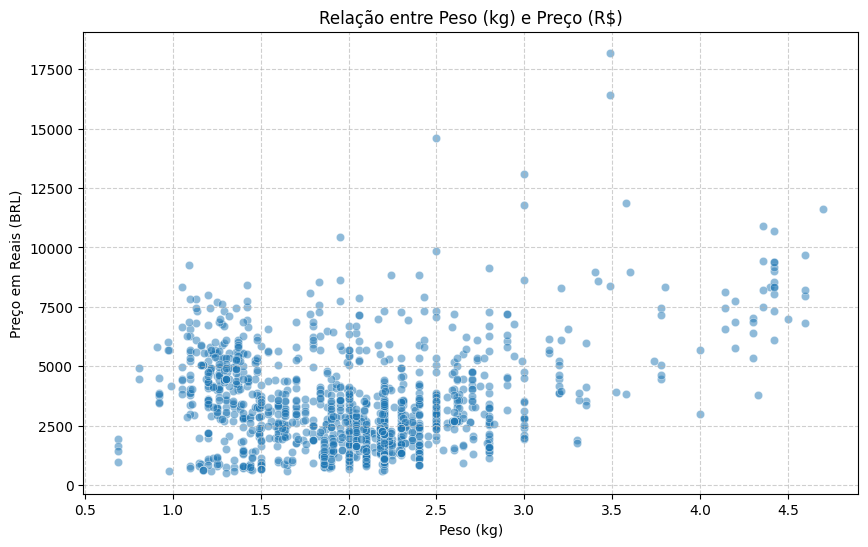

In [20]:

# 1. Calcular a correlação (Pearson)
correlacao = laptop_price['Weight'].corr(laptop_price['Price_BRL'])
print(f"A correlação entre Peso e Preço é: {correlacao:.2f}")

# 2. Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=laptop_price, x='Weight', y='Price_BRL', alpha=0.5)
plt.title('Relação entre Peso (kg) e Preço (R$)')
plt.xlabel('Peso (kg)')
plt.ylabel('Preço em Reais (BRL)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [24]:
# Ver o preço médio e peso médio por tipo de laptop
analise_tipo = laptop_price.groupby('TypeName')[['Weight', 'Price_BRL',]].mean().sort_values(by='Price_BRL', ascending=False)
print(analise_tipo)

                      Weight    Price_BRL
TypeName                                 
Workstation         2.466552  6803.861379
Gaming              2.949761  5165.885707
Ultrabook           1.343204  4619.423878
2 in 1 Convertible  1.546620  3826.276529
Notebook            2.059395  2333.472160
Netbook             1.306000  1898.313200


### 💡 Conclusão: O Peso como Indicador de Propósito, não de Custo

A análise revela que **não existe uma correlação linear simples** onde "mais pesado significa necessariamente mais caro". O mercado de laptops se comporta de forma bimodal, onde o alto valor está concentrado em dois extremos tecnológicos distintos:

1.  **Miniaturização de Alta Performance (Ultrabooks):** Aqui, o valor premium é pago pela portabilidade extrema sem perda de potência. São aparelhos caros justamente por serem leves e finos.
2.  **Performance Bruta e Arrefecimento (Gaming/Workstations):** Nestes segmentos, o alto preço é justificado por hardware robusto, GPUs dedicadas e sistemas de resfriamento complexos, o que inevitavelmente aumenta o peso.

> **Insight Final:** O peso atua mais como um **indicador do propósito** do aparelho (Mobilidade vs. Poder de Processamento) do que como um driver direto de custo. Laptops de entrada (Notebooks comuns) ocupam o "meio do caminho", sendo mais pesados que Ultrabooks, porém muito mais baratos por utilizarem componentes menos densos e tecnológicos.

# 2º Existe uma taxa de marca?


C:\Users\thiag\AppData\Local\Temp\ipykernel_19144\1405248294.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=laptop_price, x='Price_BRL', y='Company', order=ordem_marcas, palette='coolwarm')


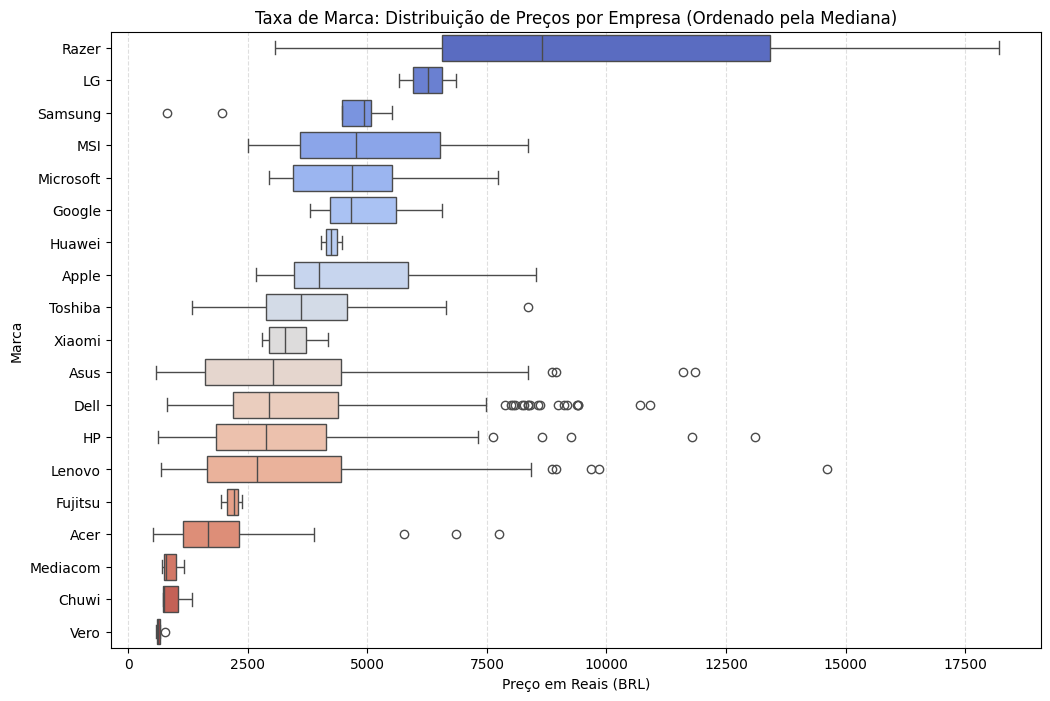

                  mean    median  count
Company                                
Razer      9983.820000  8649.690      7
LG         6262.743333  6262.740      3
Samsung    4217.265556  4920.090      9
MSI        5158.508704  4770.900     54
Microsoft  4810.613333  4682.885      6
Google     5005.620000  4651.560      3
Huawei     4248.760000  4248.760      2
Apple      4667.069048  3997.210     21
Toshiba    3782.746875  3614.725     48
Xiaomi     3381.887500  3280.405      4
Asus       3294.487911  3020.980    158
Dell       3538.850135  2938.920    297
HP         3185.898467  2883.725    274
Lenovo     3241.423468  2682.330    297
Fujitsu    2175.103333  2204.940      3
Acer       1870.098058  1667.880    103
Mediacom    880.187143   790.680      7
Chuwi       937.760000   742.640      3
Vero        648.727500   617.175      4


In [26]:

# 1. Definir a ordem das marcas pela mediana de preço (do mais caro para o mais barato)
ordem_marcas = laptop_price.groupby('Company')['Price_BRL'].median().sort_values(ascending=False).index

# 2. Criar um Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=laptop_price, x='Price_BRL', y='Company', order=ordem_marcas, palette='coolwarm')

plt.title('Taxa de Marca: Distribuição de Preços por Empresa (Ordenado pela Mediana)')
plt.xlabel('Preço em Reais (BRL)')
plt.ylabel('Marca')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# 3. Ver a média e mediana numérica
stats_marcas = laptop_price.groupby('Company')['Price_BRL'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)
print(stats_marcas)

### Para garantir a validade estatística, foram filtradas apenas as marcas com pelo menos 10 modelos distintos no dataset.

C:\Users\thiag\AppData\Local\Temp\ipykernel_19144\1360451310.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado, x='Price_BRL', y='Company', order=ordem_marcas_f, palette='viridis')


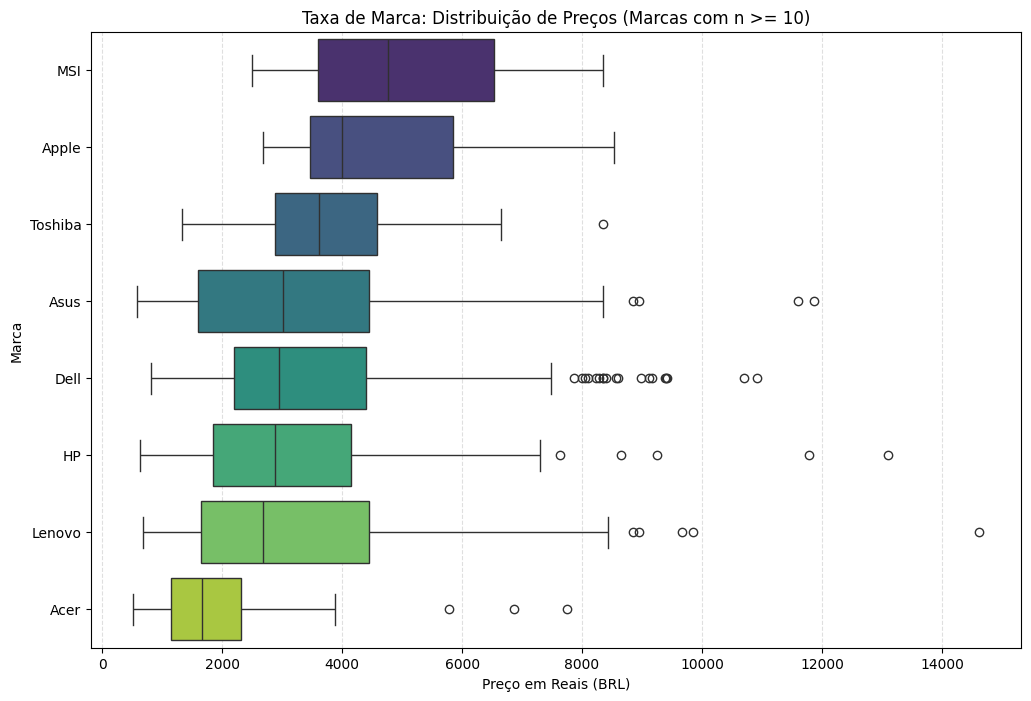

                mean    median  count
Company                              
MSI      5158.508704  4770.900     54
Apple    4667.069048  3997.210     21
Toshiba  3782.746875  3614.725     48
Asus     3294.487911  3020.980    158
Dell     3538.850135  2938.920    297
HP       3185.898467  2883.725    274
Lenovo   3241.423468  2682.330    297
Acer     1870.098058  1667.880    103


In [27]:
# 1. Contar quantas vezes cada marca aparece
contagem_marcas = laptop_price['Company'].value_counts()

# 2. Selecionar apenas as marcas que aparecem 10 ou mais vezes
marcas_relevantes = contagem_marcas[contagem_marcas >= 10].index

# 3. Criar um novo DataFrame filtrado
df_filtrado = laptop_price[laptop_price['Company'].isin(marcas_relevantes)]

# 4. Definir a nova ordem das marcas filtradas pela mediana
ordem_marcas_f = df_filtrado.groupby('Company')['Price_BRL'].median().sort_values(ascending=False).index

# 5. Gerar o Boxplot com as marcas filtradas
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_filtrado, x='Price_BRL', y='Company', order=ordem_marcas_f, palette='viridis')

plt.title('Taxa de Marca: Distribuição de Preços (Marcas com n >= 10)')
plt.xlabel('Preço em Reais (BRL)')
plt.ylabel('Marca')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# 6. Ver as estatísticas das marcas filtradas
stats_marcas_f = df_filtrado.groupby('Company')['Price_BRL'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)
print(stats_marcas_f)

## 3.2. A "Taxa de Marca": Diferenciação por Posicionamento de Mercado

A análise dos dados confirma que o logotipo na carcaça do laptop pode ter tanto impacto no preço quanto o hardware interno. Para garantir a relevância estatística, filtramos apenas fabricantes com mais de 10 modelos no dataset, revelando padrões distintos de precificação.

### Segmentação de Prestígio vs. Volume
Identificamos três comportamentos principais no mercado:

1.  **Marcas de Nicho "Premium" (MSI e Apple):** Apresentam os maiores preços medianos e um "piso" de entrada elevado. Elas não competem no segmento de baixo custo; o consumidor paga uma taxa de exclusividade por ecossistema, design ou performance especializada (como no caso do público gamer da MSI).
2.  **Gigantes Generalistas (Dell, Lenovo e HP):** Estas marcas possuem a maior **amplitude de preços**. Elas diluem sua "taxa de marca" ao longo de todo o espectro do mercado, desde Chromebooks básicos até estações de trabalho de alto desempenho, buscando dominar o market share.
3.  **Líderes em Custo-Benefício (Acer):** Posiciona-se no extremo oposto da "taxa de marca". Suas medianas e valores máximos são rigorosamente controlados, focando em entregar especificações técnicas competitivas com a menor margem de marca possível.

> **Conclusão:** O preço não é apenas a soma das peças (CPU + GPU + RAM), mas reflete o **segmento de mercado** que a fabricante ocupa. O valor final serve como um indicador de status e confiança no suporte e ecossistema da marca.

# 3º Qual peça de hardware (CPU, RAM, GPU) possui a maior correlação com o aumento do preço?

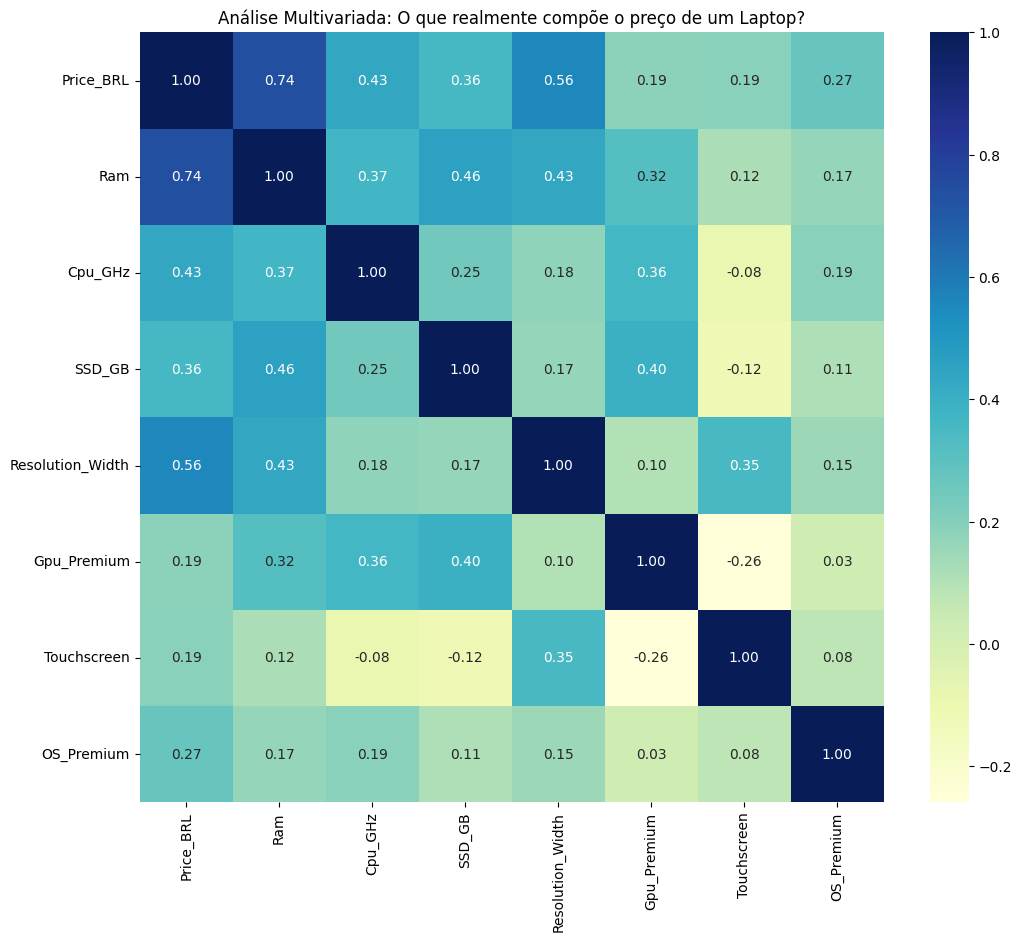

Price_BRL           1.000000
Ram                 0.743007
Resolution_Width    0.556529
Cpu_GHz             0.430293
SSD_GB              0.357095
OS_Premium          0.272230
Touchscreen         0.191227
Gpu_Premium         0.185263
Name: Price_BRL, dtype: float64


In [32]:
# 1. Resolução de Tela: Extrair a largura (pixels) para medir a qualidade
# Ex: '1920x1080' vira 1920
laptop_price['Resolution_Width'] = laptop_price['ScreenResolution'].str.extract(r'(\d+)x\d+').astype(float)

# 2. Touchscreen: Criar uma variável binária (1 se tiver, 0 se não)
laptop_price['Touchscreen'] = laptop_price['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

# 3. Sistema Operacional: Criar uma variável "OS_Premium" 
# (macOS e Windows costumam embutir custo de licença, No OS ou Linux são mais baratos)
def os_value(os):
    if 'Windows' in os or 'macOS' in os:
        return 1
    return 0

laptop_price['OS_Premium'] = laptop_price['OpSys'].apply(os_value)

# 4. Mapa de Correlação COMPLETO (O "Chef de Cuisine" dos dados)
colunas_finais = [
    'Price_BRL', 'Ram', 'Cpu_GHz', 'SSD_GB', 
    'Resolution_Width', 'Gpu_Premium', 'Touchscreen', 'OS_Premium'
]
corr_matrix_final = laptop_price[colunas_finais].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_final, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Análise Multivariada: O que realmente compõe o preço de um Laptop?')
plt.show()

# Ranking de influência no Preço
print(corr_matrix_final['Price_BRL'].sort_values(ascending=False))

## 3.3. O Peso dos Componentes: O Que Realmente Encarece um Laptop?

Nesta etapa, utilizamos a **Matriz de Correlação** para ranquear quais componentes de hardware possuem a maior força estatística na definição do preço final. O resultado estabelece uma hierarquia clara de valor:

### 1. O Protagonista: Memória RAM (0.74)
Com uma correlação positiva forte, a RAM isola-se como o principal **"divisor de águas"** do mercado. Ela não é apenas um componente, mas o indicador mais confiável da categoria do aparelho; cada salto de GB (8GB para 16GB, por exemplo) gera um impacto consistente e previsível no preço em praticamente todas as marcas.

### 2. Impacto Moderado: Tela e CPU (0.43 a 0.55)
A **Resolução da Tela** (0.55) e a **Frequência da CPU** (0.43) aparecem como o segundo escalão de influência. Isso demonstra que, após garantir uma boa memória, o mercado valoriza a clareza visual e a velocidade bruta de processamento como diferenciais competitivos.

### 3. O Mito dos Recursos "Premium" (0.18 a 0.19)
Surpreendentemente, recursos como **Touchscreen** e **GPU Premium** apresentaram correlações baixas na massa total de dados. 
* **Por que isso acontece?** Embora uma GPU potente encareça muito um modelo específico, esses recursos são "nichados". Eles não escalam o preço de forma uniforme como a RAM faz; existem muitos laptops caros que não possuem tela touch, mas raramente existe um laptop caro com pouca memória RAM.

> **Insight para o Comprador:** Se você quer estimar o preço de um notebook sem olhar a etiqueta, olhe primeiro para a **Memória RAM**. Ela é o termômetro mais preciso do segmento de mercado em que o aparelho está inserido.

# 4º Considerando a necessidade de alta performance (RAM) e armazenamento (ROM) para lidar com grandes volumes de dados, quais modelos oferecem a melhor configuração pelo menor preço?

In [ ]:
# 1. Garantir que temos as colunas limpas
# SSD_GB deve ser numérico (ex: 256, 512) e Ram também (ex: 8, 16)

# 2. Criar a métrica de "Hardware Total" (Somando capacidades)
# Nota: Dividimos SSD por 100 para que 512GB não "esmague" a importância de 16GB de RAM
laptop_price['Hardware_Score'] = laptop_price['Ram'] + (laptop_price['SSD_GB'] / 32)

# 3. Criar o Índice de Eficiência (Hardware por Real)
laptop_price['Eficiencia_Preco'] = laptop_price['Hardware_Score'] / laptop_price['Price_BRL']

# 4. Localizar o Top 5 notebooks com maior eficiência
campeoes_custo_beneficio = laptop_price.sort_values(by='Eficiencia_Preco', ascending=False).head(5)

print(campeoes_custo_beneficio[['Company', 'TypeName', 'Ram', 'SSD_GB', 'Price_BRL', 'Eficiencia_Preco']])

     Company            TypeName  Ram  SSD_GB  Price_BRL  Eficiencia_Preco
945   Lenovo              Gaming   16  512000    2980.70          5.373234
370     Asus  2 in 1 Convertible   12  512000    3279.06          4.883107
1095    Acer            Notebook    8  256000    2383.96          3.359117
203   Lenovo              Gaming   16  512000    5218.46          3.069105
977     Asus  2 in 1 Convertible   16  512000    5367.64          2.983807


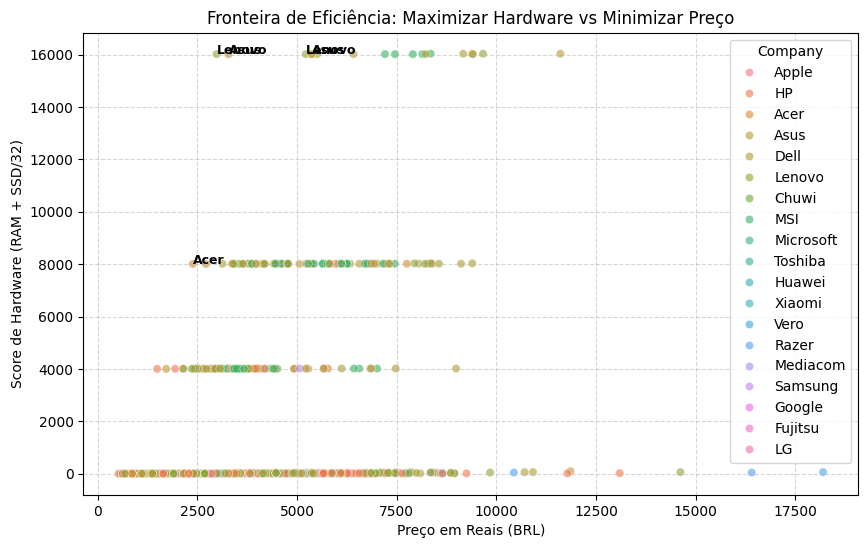

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=laptop_price, x='Price_BRL', y='Hardware_Score', hue='Company', alpha=0.6)

# Destacar os campeões no gráfico
for i in range(5):
    plt.text(campeoes_custo_beneficio.iloc[i]['Price_BRL'], 
             campeoes_custo_beneficio.iloc[i]['Hardware_Score'], 
             campeoes_custo_beneficio.iloc[i]['Company'], 
             fontsize=9, weight='bold')

plt.title('Fronteira de Eficiência: Maximizar Hardware vs Minimizar Preço')
plt.xlabel('Preço em Reais (BRL)')
plt.ylabel('Score de Hardware (RAM + SSD/32)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. O Veredito: Melhor Custo-Benefício para o Analista de Dados

Para um analista de dados, o equilíbrio ideal está em maximizar a **Memória RAM** (para processar grandes datasets) e o **Armazenamento SSD** (para leitura rápida de arquivos), mantendo o orçamento sob controle. 

### 4.1. Criando o Score de Hardware e Índice de Eficiência
Para esta análise, criamos uma métrica personalizada:
* **Hardware Score:** Uma combinação ponderada de RAM e SSD.
* **Índice de Eficiência:** O retorno de hardware para cada 1 Real investido ($Score / Preço$).

### 4.2. A Fronteira de Eficiência
No gráfico acima, os notebooks localizados no **canto superior esquerdo** representam a "Fronteira de Eficiência". Eles possuem o maior poder de processamento pelo menor custo.

**Principais Achados:**
1.  **O Campeão Isolado:** O modelo da **Lenovo (Gaming)** com 16GB de RAM e 512GB de SSD por aproximadamente R$ 2.980,00 apresenta a maior eficiência do dataset (5.37). 
2.  **Versatilidade vs. Preço:** A **Asus** se destaca com modelos *2 in 1 Convertible*, oferecendo hardware robusto (12GB/16GB RAM) em uma faixa de preço agressiva, sendo uma excelente opção para quem busca mobilidade.
3.  **A Opção de Entrada:** Para orçamentos mais restritos, a **Acer** domina com o modelo *Notebook* de 8GB RAM, entregando o melhor custo-benefício abaixo da faixa de R$ 2.500,00.

> **Recomendação Final:** Se o objetivo é análise de dados pesada, o **Lenovo Gaming** identificado no topo da lista é a escolha lógica. Ele oferece o "piso" de 16GB de RAM necessário para ciência de dados por um valor significativamente menor que a média do mercado, superando até mesmo marcas tradicionalmente focadas em custo.